# 04 Exploratory Data Analysis

**Project:** AI-Powered Customer Retention Decision Support System for E-Commerce  
**Input table:** `customer_modeling_90d.csv`  
**Goal:** Compare customers who purchased again within 90 days against customers who became inactive.

This notebook turns the 90-day churn/inactivity label into business-readable insights. The analysis focuses
on behavioral differences that can later support modeling, dashboard design, and retention recommendations.

> **Data safety note:** this notebook does **not** overwrite EDA summary tables unless `SAVE_OUTPUTS` is
> manually changed to `True`.

## Executive Insights

This EDA supports four early retention signals:

1. **Recency is a strong signal.** Active customers are mostly clustered at low recency, meaning they
   purchased more recently. Inactive customers are spread much farther out, especially around 250+ days since
   last purchase.
2. **Inactive customers have lower frequency.** Most inactive customers only have a few orders. Active
   customers also include many low-frequency customers, but they have more customers with higher order counts.
3. **Active customers have higher monetary value.** The log monetary value chart shifts to the right for active
   customers, meaning active customers tend to spend more.
4. **Active customers have higher product diversity.** Active customers bought a wider variety of products,
   while inactive customers are more concentrated at lower diversity levels.

## 1. Setup

In [7]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 70)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.ticker import FuncFormatter, PercentFormatter

    HAS_PLOTS = True
    STATUS_COLORS = {
        "Active": "#2A9D8F",
        "Inactive": "#E76F51",
    }
    sns.set_theme(
        style="whitegrid",
        context="notebook",
        rc={
            "figure.figsize": (11, 5),
            "axes.titleweight": "bold",
            "axes.titlesize": 14,
            "axes.labelsize": 11,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "legend.frameon": False,
        },
    )
except ImportError:
    HAS_PLOTS = False
    STATUS_COLORS = {"Active": "#2A9D8F", "Inactive": "#E76F51"}
    print("Plotting libraries are not available in this environment; chart cells will be skipped.")

In [8]:
# Resolve project paths from the notebook location.
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = (
    NOTEBOOK_DIR.parent
    if NOTEBOOK_DIR.name == "notebooks"
    else Path(r"C:/Learning/BANA8083/AI-retention-decision-support")
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELING_PATH = PROCESSED_DIR / "customer_modeling_90d.csv"
EDA_OUTPUT_DIR = PROCESSED_DIR / "eda_summary_tables"

# Keep this False unless you intentionally want to regenerate the saved EDA summary tables.
SAVE_OUTPUTS = False

paths = pd.DataFrame(
    {
        "asset": ["processed directory", "90-day modeling dataset", "EDA summary output directory"],
        "path": [PROCESSED_DIR, MODELING_PATH, EDA_OUTPUT_DIR],
        "exists": [PROCESSED_DIR.exists(), MODELING_PATH.exists(), EDA_OUTPUT_DIR.exists()],
    }
)
paths

,asset,path,exists
0,processed directory,c:\Learning\BANA8083\AI-retention-decision-sup...,True
1,90-day modeling dataset,c:\Learning\BANA8083\AI-retention-decision-sup...,True
2,EDA summary output directory,c:\Learning\BANA8083\AI-retention-decision-sup...,True


## 2. Load Modeling Dataset

In [9]:
customer_model = pd.read_csv(
    MODELING_PATH,
    parse_dates=["first_purchase_date", "last_purchase_date"],
)

customer_model["customer_status"] = customer_model["inactive_90d"].map(
    {0: "Active", 1: "Inactive"}
)
customer_model["log_monetary_value"] = np.log1p(customer_model["monetary_value"])
customer_model["log_product_diversity"] = np.log1p(customer_model["product_diversity"])

print(f"Rows: {len(customer_model):,}")
print(f"Columns: {customer_model.shape[1]:,}")
print(f"Customers: {customer_model['CustomerID'].nunique():,}")
customer_model.head()

Rows: 5,281
Columns: 24
Customers: 5,281


,CustomerID,first_purchase_date,last_purchase_date,frequency,monetary_value,avg_order_value,total_quantity,avg_basket_quantity,avg_products_per_order,recency,customer_lifetime_days,product_diversity,description_diversity,primary_country,return_cancel_rows,return_cancel_invoices,return_cancel_quantity,return_cancel_value,return_cancel_rate,active_90d,inactive_90d,customer_status,log_monetary_value,log_product_diversity
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,12,"77,556.460","6,463.038",74285,"6,190.417",2.833,235,400,27,26,United Kingdom,13.000,5.000,"74,232.000","77,608.200",0.417,0,1,Inactive,11.259,3.332
1,12347,2010-10-31 14:20:00,2011-08-02 08:48:00,6,"3,402.390",567.065,2099,349.833,27.333,39,274,107,107,Iceland,0.000,0.000,0.000,0.000,0.000,1,0,Active,8.133,4.682
2,12348,2010-09-27 14:59:00,2011-04-05 10:47:00,4,"1,709.400",427.350,2497,624.250,11.000,158,189,25,28,Finland,0.000,0.000,0.000,0.000,0.000,1,0,Active,7.444,3.258
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,3,"2,671.140",890.380,993,331.000,34.000,317,181,90,94,Italy,5.000,1.000,5.000,24.150,0.333,1,0,Active,7.891,4.511
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.400,334.400,197,197.000,17.000,219,0,17,17,Norway,0.000,0.000,0.000,0.000,0.000,0,1,Inactive,5.815,2.890


In [10]:
quality_checks = pd.DataFrame(
    {
        "check": [
            "rows",
            "unique_customers",
            "duplicate_customer_rows",
            "missing_status",
            "inactive_customers",
            "active_customers",
        ],
        "value": [
            len(customer_model),
            customer_model["CustomerID"].nunique(),
            customer_model["CustomerID"].duplicated().sum(),
            customer_model["customer_status"].isna().sum(),
            int(customer_model["inactive_90d"].sum()),
            int(customer_model["active_90d"].sum()),
        ],
    }
)
quality_checks

,check,value
0,rows,5281
1,unique_customers,5281
2,duplicate_customer_rows,0
3,missing_status,0
4,inactive_customers,2989
5,active_customers,2292


## 3. Overall 90-Day Activity Balance

In [11]:
label_summary = (
    customer_model
    .groupby(["inactive_90d", "customer_status"], as_index=False)
    .agg(customer_count=("CustomerID", "count"))
    .sort_values("inactive_90d", ascending=False)
    .reset_index(drop=True)
)
label_summary["percentage"] = label_summary["customer_count"] / label_summary["customer_count"].sum()
label_summary

,inactive_90d,customer_status,customer_count,percentage
0,1,Inactive,2989,0.566
1,0,Active,2292,0.434


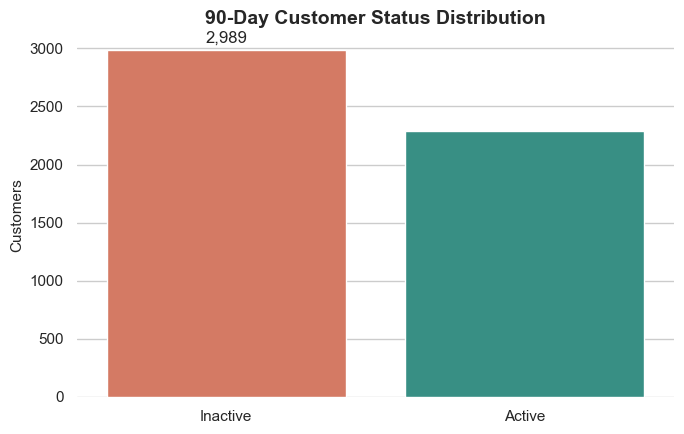

In [12]:
if HAS_PLOTS:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    sns.barplot(
        data=label_summary,
        x="customer_status",
        y="customer_count",
        hue="customer_status",
        palette=STATUS_COLORS,
        dodge=False,
        ax=ax,
    )
    ax.set_title("90-Day Customer Status Distribution")
    ax.set_xlabel("")
    ax.set_ylabel("Customers")
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
    ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=3)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping chart because plotting libraries are not available.")

**Takeaway:** The modeling dataset has more inactive than active customers. This means future modeling should
evaluate recall, precision, F1-score, and ROC-AUC instead of relying on accuracy alone.

## 4. Active vs. Inactive Summary Table

In [13]:
numeric_cols = [
    "recency",
    "frequency",
    "monetary_value",
    "avg_order_value",
    "customer_lifetime_days",
    "product_diversity",
    "description_diversity",
    "return_cancel_rate",
]

comparison = (
    customer_model
    .groupby("customer_status")[numeric_cols]
    .agg(["mean", "median"])
    .round(2)
)
comparison

recency         frequency        monetary_value            \
                   mean  median      mean median           mean    median   
customer_status                                                             
Active          120.040  67.000     9.250  5.000      4,598.240 1,605.440   
Inactive        274.180 287.000     3.050  2.000      1,134.620   486.820   

                avg_order_value         customer_lifetime_days          \
                           mean  median                   mean  median   
customer_status                                                          
Active                  395.040 306.690                320.480 345.500   
Inactive                349.550 246.750                150.280  47.000   

                product_diversity        description_diversity         \
                             mean median                  mean median   
customer_status                                                         
Active                    112.020 72.000               115.670 73.500   
Inactive                   45.480 28.000                46.060 28.000   

                return_cancel_rate         
                              mean median  
customer_status                            
Active                       0.220  0.110  
Inactive                     0.190  0.000

In [14]:
business_summary = (
    customer_model
    .groupby("customer_status")
    .agg(
        customers=("CustomerID", "count"),
        median_recency=("recency", "median"),
        median_frequency=("frequency", "median"),
        median_monetary_value=("monetary_value", "median"),
        median_product_diversity=("product_diversity", "median"),
        avg_return_cancel_rate=("return_cancel_rate", "mean"),
    )
    .reset_index()
)
business_summary

,customer_status,customers,median_recency,median_frequency,median_monetary_value,median_product_diversity,avg_return_cancel_rate
0,Active,2292,67.000,5.000,"1,605.440",72.000,0.216
1,Inactive,2989,287.000,2.000,486.820,28.000,0.193


## 5. Recency: Recent Purchases Separate Active Customers

In [15]:
recency_summary = (
    customer_model
    .groupby("customer_status")
    .agg(
        customers=("CustomerID", "count"),
        mean_recency=("recency", "mean"),
        median_recency=("recency", "median"),
        pct_90_days_or_less=("recency", lambda x: (x <= 90).mean()),
        pct_250_days_or_more=("recency", lambda x: (x >= 250).mean()),
    )
    .reset_index()
)
recency_summary

,customer_status,customers,mean_recency,median_recency,pct_90_days_or_less,pct_250_days_or_more
0,Active,2292,120.043,67.000,0.574,0.194
1,Inactive,2989,274.179,287.000,0.198,0.555


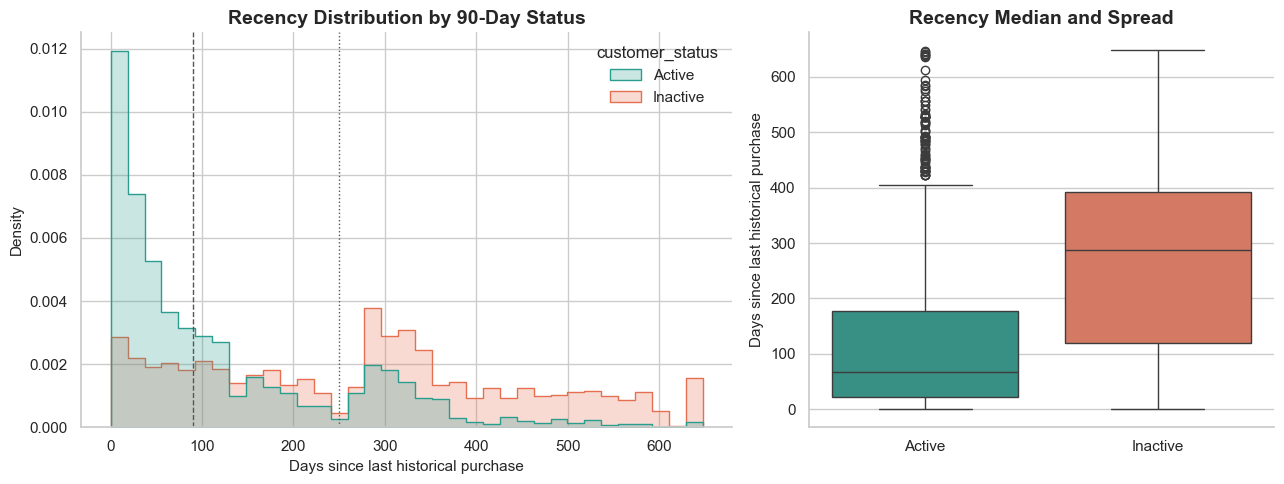

In [16]:
if HAS_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.4, 1]})

    sns.histplot(
        data=customer_model,
        x="recency",
        hue="customer_status",
        hue_order=["Active", "Inactive"],
        palette=STATUS_COLORS,
        bins=35,
        stat="density",
        common_norm=False,
        element="step",
        fill=True,
        alpha=0.25,
        ax=axes[0],
    )
    axes[0].axvline(90, color="#555555", linestyle="--", linewidth=1)
    axes[0].axvline(250, color="#555555", linestyle=":", linewidth=1)
    axes[0].set_title("Recency Distribution by 90-Day Status")
    axes[0].set_xlabel("Days since last historical purchase")
    axes[0].set_ylabel("Density")

    sns.boxplot(
        data=customer_model,
        x="customer_status",
        y="recency",
        order=["Active", "Inactive"],
        palette=STATUS_COLORS,
        ax=axes[1],
    )
    axes[1].set_title("Recency Median and Spread")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Days since last historical purchase")

    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("Skipping chart because plotting libraries are not available.")

**Insight: Recency is a strong signal.** Active customers are mostly clustered at low recency, meaning they
purchased more recently. Inactive customers are spread much farther out, especially around **250+ days since
last purchase**. This makes recency one of the clearest behavioral indicators for retention risk.

## 6. Frequency: Inactive Customers Usually Have Fewer Orders

In [17]:
frequency_summary = (
    customer_model
    .groupby("customer_status")
    .agg(
        customers=("CustomerID", "count"),
        mean_frequency=("frequency", "mean"),
        median_frequency=("frequency", "median"),
        pct_three_orders_or_less=("frequency", lambda x: (x <= 3).mean()),
        pct_more_than_six_orders=("frequency", lambda x: (x > 6).mean()),
    )
    .reset_index()
)
frequency_summary

,customer_status,customers,mean_frequency,median_frequency,pct_three_orders_or_less,pct_more_than_six_orders
0,Active,2292,9.255,5.000,0.368,0.421
1,Inactive,2989,3.055,2.000,0.739,0.094


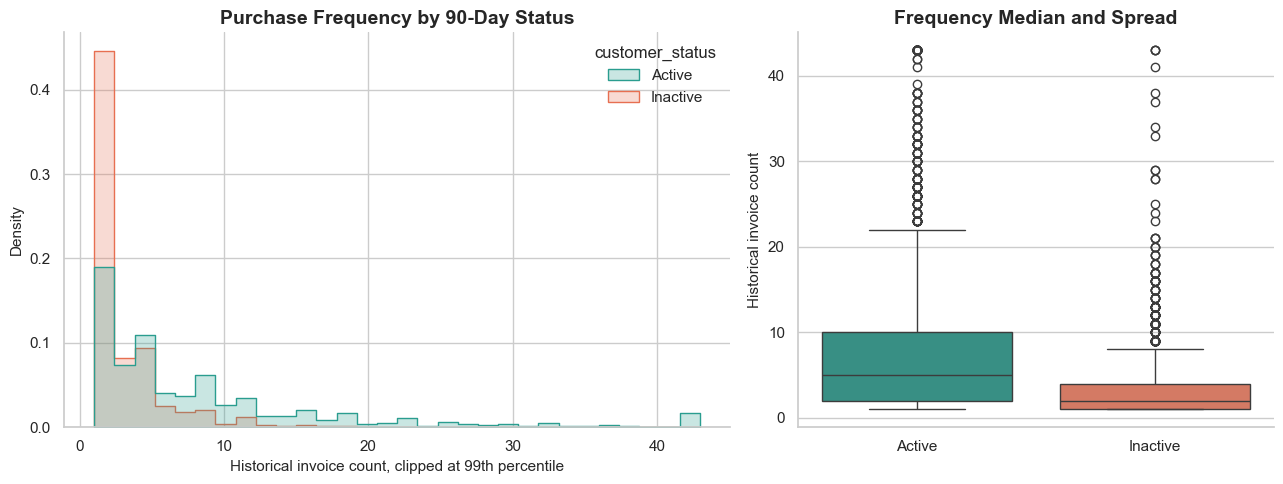

In [18]:
if HAS_PLOTS:
    frequency_cap = customer_model["frequency"].quantile(0.99)
    plot_data = customer_model.assign(
        frequency_clipped=customer_model["frequency"].clip(upper=frequency_cap)
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.4, 1]})

    sns.histplot(
        data=plot_data,
        x="frequency_clipped",
        hue="customer_status",
        hue_order=["Active", "Inactive"],
        palette=STATUS_COLORS,
        bins=30,
        stat="density",
        common_norm=False,
        element="step",
        fill=True,
        alpha=0.25,
        ax=axes[0],
    )
    axes[0].set_title("Purchase Frequency by 90-Day Status")
    axes[0].set_xlabel("Historical invoice count, clipped at 99th percentile")
    axes[0].set_ylabel("Density")

    sns.boxplot(
        data=plot_data,
        x="customer_status",
        y="frequency_clipped",
        order=["Active", "Inactive"],
        palette=STATUS_COLORS,
        ax=axes[1],
    )
    axes[1].set_title("Frequency Median and Spread")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Historical invoice count")

    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("Skipping chart because plotting libraries are not available.")

**Insight: Inactive customers have lower frequency.** Most inactive customers only have a few orders. Active
customers also include many low-frequency customers, but they have more customers with higher order counts.
Frequency should help the model distinguish casual one-time buyers from more established customers.

## 7. Monetary Value: Active Customers Tend to Spend More

In [19]:
monetary_summary = (
    customer_model
    .groupby("customer_status")
    .agg(
        customers=("CustomerID", "count"),
        mean_monetary_value=("monetary_value", "mean"),
        median_monetary_value=("monetary_value", "median"),
        mean_log_monetary_value=("log_monetary_value", "mean"),
        median_log_monetary_value=("log_monetary_value", "median"),
    )
    .reset_index()
)
monetary_summary

,customer_status,customers,mean_monetary_value,median_monetary_value,mean_log_monetary_value,median_log_monetary_value
0,Active,2292,"4,598.243","1,605.440",7.378,7.382
1,Inactive,2989,"1,134.621",486.820,6.243,6.190


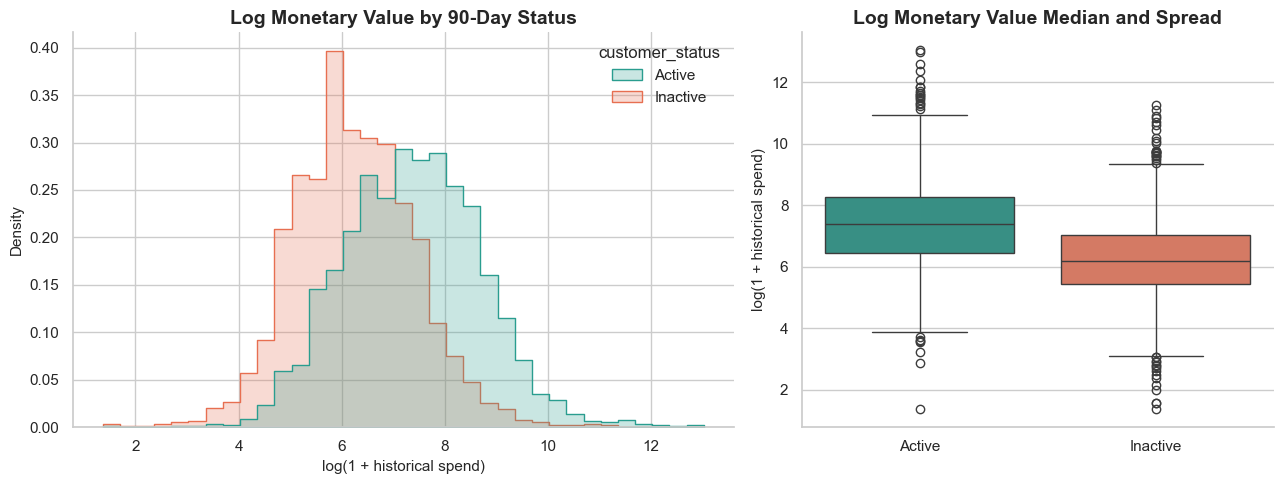

In [20]:
if HAS_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.4, 1]})

    sns.histplot(
        data=customer_model,
        x="log_monetary_value",
        hue="customer_status",
        hue_order=["Active", "Inactive"],
        palette=STATUS_COLORS,
        bins=35,
        stat="density",
        common_norm=False,
        element="step",
        fill=True,
        alpha=0.25,
        ax=axes[0],
    )
    axes[0].set_title("Log Monetary Value by 90-Day Status")
    axes[0].set_xlabel("log(1 + historical spend)")
    axes[0].set_ylabel("Density")

    sns.boxplot(
        data=customer_model,
        x="customer_status",
        y="log_monetary_value",
        order=["Active", "Inactive"],
        palette=STATUS_COLORS,
        ax=axes[1],
    )
    axes[1].set_title("Log Monetary Value Median and Spread")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("log(1 + historical spend)")

    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("Skipping chart because plotting libraries are not available.")

**Insight: Active customers have higher monetary value.** The log monetary value chart clearly shifts to the
right for active customers. That means active customers tend to spend more, while inactive customers are more
concentrated among lower-spend customers.

## 8. Product Diversity: Active Customers Buy a Wider Mix

In [21]:
diversity_summary = (
    customer_model
    .groupby("customer_status")
    .agg(
        customers=("CustomerID", "count"),
        mean_product_diversity=("product_diversity", "mean"),
        median_product_diversity=("product_diversity", "median"),
        mean_description_diversity=("description_diversity", "mean"),
        median_description_diversity=("description_diversity", "median"),
    )
    .reset_index()
)
diversity_summary

,customer_status,customers,mean_product_diversity,median_product_diversity,mean_description_diversity,median_description_diversity
0,Active,2292,112.021,72.000,115.673,73.500
1,Inactive,2989,45.475,28.000,46.063,28.000


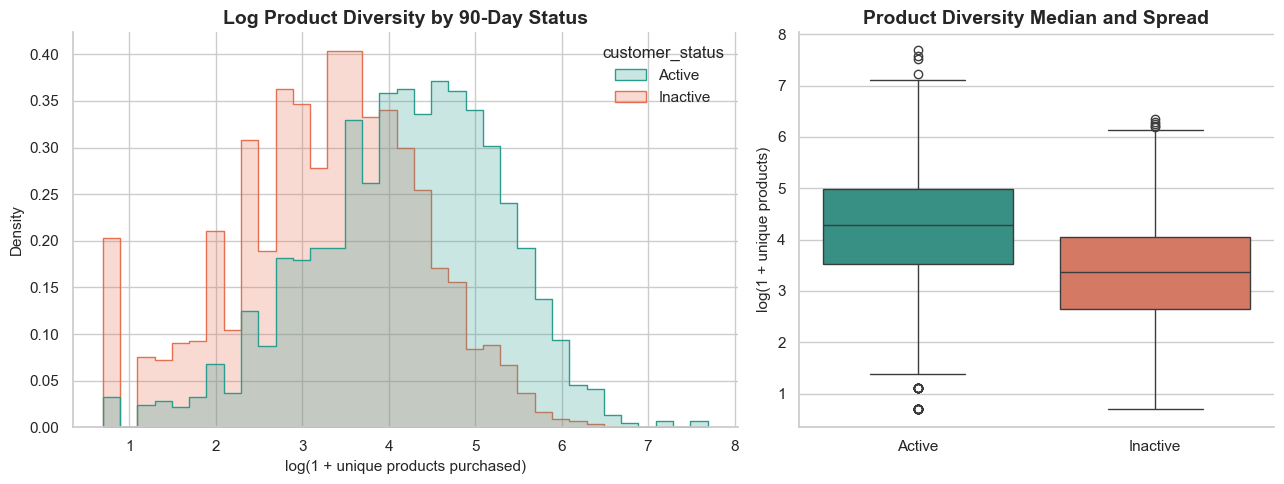

In [22]:
if HAS_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.4, 1]})

    sns.histplot(
        data=customer_model,
        x="log_product_diversity",
        hue="customer_status",
        hue_order=["Active", "Inactive"],
        palette=STATUS_COLORS,
        bins=35,
        stat="density",
        common_norm=False,
        element="step",
        fill=True,
        alpha=0.25,
        ax=axes[0],
    )
    axes[0].set_title("Log Product Diversity by 90-Day Status")
    axes[0].set_xlabel("log(1 + unique products purchased)")
    axes[0].set_ylabel("Density")

    sns.boxplot(
        data=customer_model,
        x="customer_status",
        y="log_product_diversity",
        order=["Active", "Inactive"],
        palette=STATUS_COLORS,
        ax=axes[1],
    )
    axes[1].set_title("Product Diversity Median and Spread")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("log(1 + unique products)")

    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("Skipping chart because plotting libraries are not available.")

**Insight: Active customers have higher product diversity.** Active customers bought a wider variety of
products, while inactive customers are more concentrated at lower diversity levels. This suggests breadth of
engagement may be useful for both segmentation and churn prediction.

## 9. Relationship View: Recency and Value Together

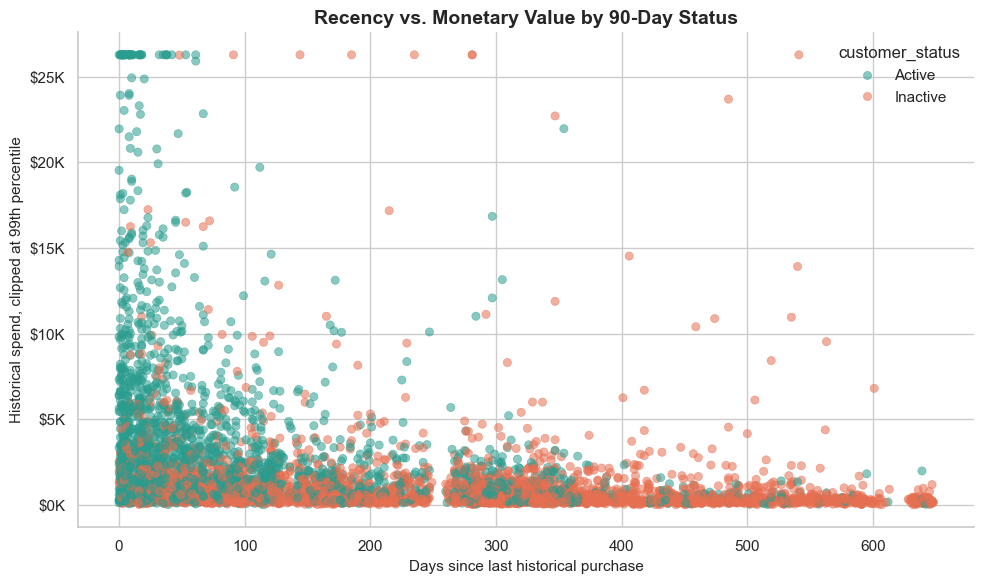

In [23]:
if HAS_PLOTS:
    scatter_data = customer_model.copy()
    monetary_cap = scatter_data["monetary_value"].quantile(0.99)
    scatter_data["monetary_value_clipped"] = scatter_data["monetary_value"].clip(upper=monetary_cap)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.scatterplot(
        data=scatter_data,
        x="recency",
        y="monetary_value_clipped",
        hue="customer_status",
        hue_order=["Active", "Inactive"],
        palette=STATUS_COLORS,
        alpha=0.55,
        s=35,
        edgecolor=None,
        ax=ax,
    )
    ax.set_title("Recency vs. Monetary Value by 90-Day Status")
    ax.set_xlabel("Days since last historical purchase")
    ax.set_ylabel("Historical spend, clipped at 99th percentile")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value/1_000:.0f}K"))
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("Skipping chart because plotting libraries are not available.")

**Interpretation:** The highest-risk area is customers with older recency and lower value, but the scatterplot
also helps identify higher-value inactive customers who may be worth targeted win-back campaigns.

## 10. Country-Level Context

In [24]:
country_summary = (
    customer_model
    .groupby("primary_country")
    .agg(
        customers=("CustomerID", "count"),
        inactive_rate=("inactive_90d", "mean"),
        avg_monetary_value=("monetary_value", "mean"),
        median_monetary_value=("monetary_value", "median"),
        avg_frequency=("frequency", "mean"),
        median_recency=("recency", "median"),
    )
    .reset_index()
    .sort_values(["customers", "inactive_rate"], ascending=[False, False])
)

country_summary.head(15)

,primary_country,customers,inactive_rate,avg_monetary_value,median_monetary_value,avg_frequency,median_recency
38,United Kingdom,4814,0.569,"2,387.308",746.205,5.736,167.500
14,Germany,92,0.402,"3,743.080","1,795.865",6.707,76.000
13,France,78,0.436,"3,370.439",951.690,6.026,73.000
32,Spain,33,0.545,"2,597.461",628.150,3.576,169.000
3,Belgium,27,0.407,"1,807.293","1,227.820",4.370,84.000
24,Netherlands,22,0.727,"20,496.518",823.230,8.682,354.500
28,Portugal,20,0.600,"2,157.503",924.870,3.400,207.000
34,Switzerland,20,0.500,"3,950.552","2,222.410",4.000,109.500
33,Sweden,19,0.737,"4,132.825",733.910,4.895,318.000
0,Australia,14,0.571,"10,176.039",519.045,5.500,230.500


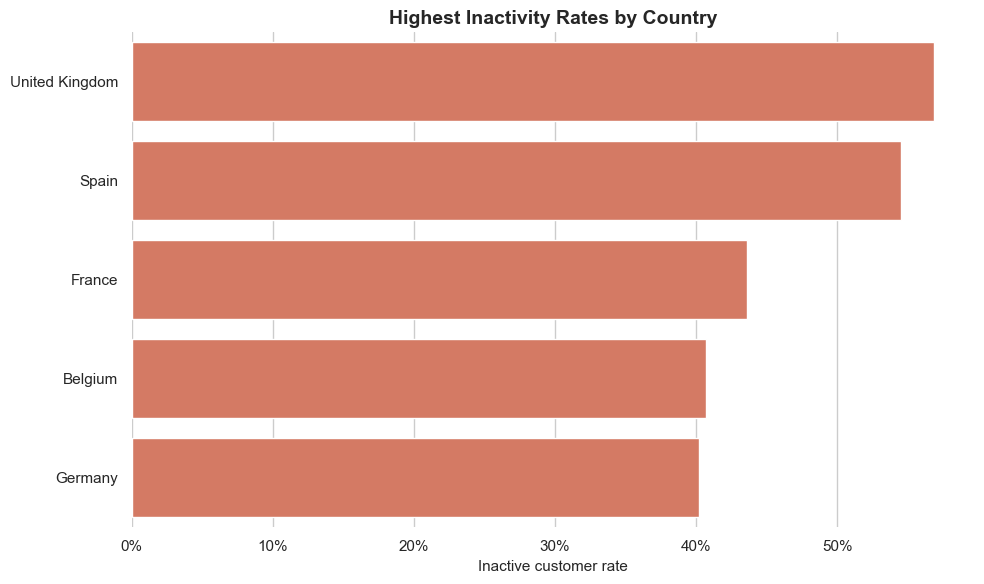

In [25]:
if HAS_PLOTS:
    country_plot = country_summary[country_summary["customers"] >= 25].copy()
    country_plot = country_plot.sort_values("inactive_rate", ascending=False).head(12)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(
        data=country_plot,
        x="inactive_rate",
        y="primary_country",
        color="#E76F51",
        ax=ax,
    )
    ax.set_title("Highest Inactivity Rates by Country")
    ax.set_xlabel("Inactive customer rate")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping chart because plotting libraries are not available.")

**Interpretation:** Country-level differences can be useful for dashboard filtering, but they should be treated
carefully because smaller countries can have unstable rates. Use minimum customer-count thresholds before
making market-specific recommendations.

## 11. Analysis Summary for Report

In [26]:
insight_summary = pd.DataFrame(
    [
        {
            "finding": "Recency is a strong signal",
            "evidence": "Active customers have much lower median recency than inactive customers.",
            "business_implication": "Recent purchasers are more likely to remain active; older recency should trigger retention attention.",
        },
        {
            "finding": "Inactive customers have lower frequency",
            "evidence": "Inactive customers are concentrated among customers with only a few historical orders.",
            "business_implication": "Low-frequency customers may need onboarding, reminders, or low-cost reactivation campaigns.",
        },
        {
            "finding": "Active customers have higher monetary value",
            "evidence": "The active-customer monetary distribution shifts right on the log spend scale.",
            "business_implication": "High-value active behavior can guide segment definitions and value-based retention prioritization.",
        },
        {
            "finding": "Active customers have higher product diversity",
            "evidence": "Active customers show higher product diversity than inactive customers.",
            "business_implication": "Broader product engagement may indicate stronger customer relationship depth.",
        },
    ]
)
insight_summary

,finding,evidence,business_implication
0,Recency is a strong signal,Active customers have much lower median recenc...,Recent purchasers are more likely to remain ac...
1,Inactive customers have lower frequency,Inactive customers are concentrated among cust...,"Low-frequency customers may need onboarding, r..."
2,Active customers have higher monetary value,The active-customer monetary distribution shif...,High-value active behavior can guide segment d...
3,Active customers have higher product diversity,Active customers show higher product diversity...,Broader product engagement may indicate strong...


## 12. Optional Export

Existing EDA summary tables are protected by default. If you intentionally want to overwrite them after
reviewing the notebook, change `SAVE_OUTPUTS` to `True` in the setup cell and rerun this cell.

In [ ]:
if SAVE_OUTPUTS:
    EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    label_summary.to_csv(EDA_OUTPUT_DIR / "label_summary_readable.csv", index=False)
    comparison.to_csv(EDA_OUTPUT_DIR / "active_vs_inactive_comparison.csv")
    country_summary.to_csv(EDA_OUTPUT_DIR / "country_summary.csv", index=False)
    insight_summary.to_csv(EDA_OUTPUT_DIR / "insight_summary.csv", index=False)
    print(f"EDA summary tables were overwritten because SAVE_OUTPUTS=True: {EDA_OUTPUT_DIR}")
else:
    print("SAVE_OUTPUTS=False, so EDA summary tables were not written or overwritten.")

## 13. Output Readiness

This notebook is ready for the capstone narrative when:

1. The plots clearly distinguish active and inactive customers.
2. Each visual has a direct business interpretation.
3. Recency, frequency, monetary value, and product diversity are documented as candidate churn-risk drivers.
4. Summary-table exports remain off unless an intentional regeneration is needed.

Recommended next notebook: `05_modeling.ipynb`